# EDA — Precos de Combustiveis no DF
**Projeto:** Sistema Inteligente de Previsao de Precos
**Dados:** ANP | Periodo: 2023-2026

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12

PROCESSED_DIR = Path('../..') / 'data' / 'processed'
df = pd.read_parquet(PROCESSED_DIR / 'precos_df.parquet')
df['data_coleta'] = pd.to_datetime(df['data_coleta'])
df['mes'] = df['data_coleta'].dt.month
df['ano'] = df['data_coleta'].dt.year
df['dia_semana'] = df['data_coleta'].dt.day_name()
df['semana'] = df['data_coleta'].dt.to_period('W').dt.start_time
print(f'Registros: {len(df):,}')
print(f'Periodo: {df.data_coleta.min().date()} ate {df.data_coleta.max().date()}')
print(f'Produtos: {df.produto.nunique()}')
print(f'Municipios: {df.municipio.nunique()}')
print(f'Bairros: {df.bairro.nunique()}')
print(f'Regioes: {df.regiao.nunique()}')
print(f'Postos: {df.cnpj.nunique()}')
df.head()

Registros: 27,213
Periodo: 2023-02-10 ate 2026-12-02
Produtos: 7
Municipios: 1
Bairros: 66
Regioes: 38
Postos: 238


,cnpj,razao_social,nome_fantasia,endereco,numero,complemento,bairro,cep,municipio,estado,...,produto,unidade,preco_revenda,data_coleta,is_botijao,regiao,mes,ano,dia_semana,semana
0,7917405000138,BANTA COMERCIO DE COMBUSTIVEIS LTDA,POSTO GARZZO,AREA ADE CONJUNTO 23,LT 35,E 36,AREA DE DESENVOLVIMENTO ECONOMICO (AGUAS CLARAS),71990180,BRASILIA,DISTRITO FEDERAL,...,DIESEL S10,R$ / LITRO,6.29,2023-02-10,False,AGUAS CLARAS,2,2023,Friday,2023-02-06
1,306597009315,CASCOL COMBUSTIVEIS PARA VEICULOS LTDA,CASCOL COMBUSTIVEIS PARA VEICULOS LTDA,QUADRA QS 09 RUA 120 LOTE,28,None,AGUAS CLARAS,71977180,BRASILIA,DISTRITO FEDERAL,...,DIESEL S10,R$ / LITRO,6.25,2023-02-10,False,AGUAS CLARAS,2,2023,Friday,2023-02-06
2,306597005590,CASCOL COMBUSTIVEIS PARA VEICULOS LTDA,CASCOL COMBUSTIVEIS PARA VEICULOS LTDA,SEGUNDA AVENIDA SEGUNDA AV. NORTE LOTE,45211,None,SAMAMBAIA,72320000,BRASILIA,DISTRITO FEDERAL,...,DIESEL S10,R$ / LITRO,6.31,2023-02-10,False,SAMAMBAIA,2,2023,Friday,2023-02-06
3,306597008777,CASCOL COMBUSTIVEIS PARA VEICULOS LTDA,CASCOL COMBUSTIVEIS PARA VEICULOS LTDA,QUADRA QN 122 CONJUNTO 07 LOTE,6,None,SAMAMBAIA,72310108,BRASILIA,DISTRITO FEDERAL,...,DIESEL S10,R$ / LITRO,6.30,2023-02-10,False,SAMAMBAIA,2,2023,Friday,2023-02-06
4,306597006804,CASCOL COMBUSTIVEIS PARA VEICULOS LTDA,CASCOL COMBUSTIVEIS PARA VEICULOS LTDA,QUADRA QSE AREA ESPECIAL PARA POSTO DE COMBUST...,S/N,None,TAGUATINGA,72025001,BRASILIA,DISTRITO FEDERAL,...,DIESEL S10,R$ / LITRO,6.15,2023-02-10,False,TAGUATINGA,2,2023,Friday,2023-02-06


## 1. Visao Geral dos Dados

In [31]:
print('=== Informacoes Gerais ===')
print(df.dtypes)
print()
print('=== Valores Nulos ===')
print(df.isnull().sum())
print()
print('=== Estatisticas Descritivas ===')
df.groupby('produto')['preco_revenda'].describe().round(2)

=== Informacoes Gerais ===
cnpj                     object
razao_social             object
nome_fantasia            object
endereco                 object
numero                   object
complemento              object
bairro                   object
cep                      object
municipio                object
estado                   object
bandeira                 object
produto                  object
unidade                  object
preco_revenda           float64
data_coleta      datetime64[ns]
is_botijao                 bool
regiao                   object
mes                       int32
ano                       int32
dia_semana               object
semana           datetime64[ns]
dtype: object

=== Valores Nulos ===
cnpj                 0
razao_social         0
nome_fantasia        0
endereco             0
numero             153
complemento      19418
bairro               0
cep                  0
municipio            0
estado               0
bandeira             0
produto    

,count,mean,std,min,25%,50%,75%,max
produto,,,,,,,,
DIESEL S10,2786.0,5.94,0.40,4.68,5.81,5.98,6.19,6.99
DIESEL S500,2638.0,5.89,0.41,4.65,5.77,5.95,6.13,7.02
ETANOL,4158.0,4.09,0.47,3.28,3.69,3.99,4.50,5.27
GASOLINA ADITIVADA,5736.0,6.09,0.41,4.99,5.79,6.08,6.48,7.29
GASOLINA COMUM,6391.0,6.03,0.42,4.95,5.69,5.99,6.46,6.89
GLP,5487.0,98.18,6.72,77.99,94.99,97.99,101.99,120.00
GNV,17.0,6.57,0.25,6.04,6.69,6.69,6.69,6.69


## 2. Evolucao de Preco ao Longo do Tempo

In [32]:
produtos_principais = ['GASOLINA COMUM', 'ETANOL', 'DIESEL S10']
df_plot = df[df['produto'].isin(produtos_principais)]
preco_semanal = df_plot.groupby(['semana', 'produto'])['preco_revenda'].mean().reset_index()

fig = px.line(
    preco_semanal,
    x='semana', y='preco_revenda', color='produto',
    title='Evolucao Semanal do Preco Medio — DF',
    labels={'preco_revenda': 'Preco Medio (R$)', 'semana': 'Data', 'produto': 'Produto'},
    template='plotly_white'
)
fig.update_layout(hovermode='x unified')
fig.show()

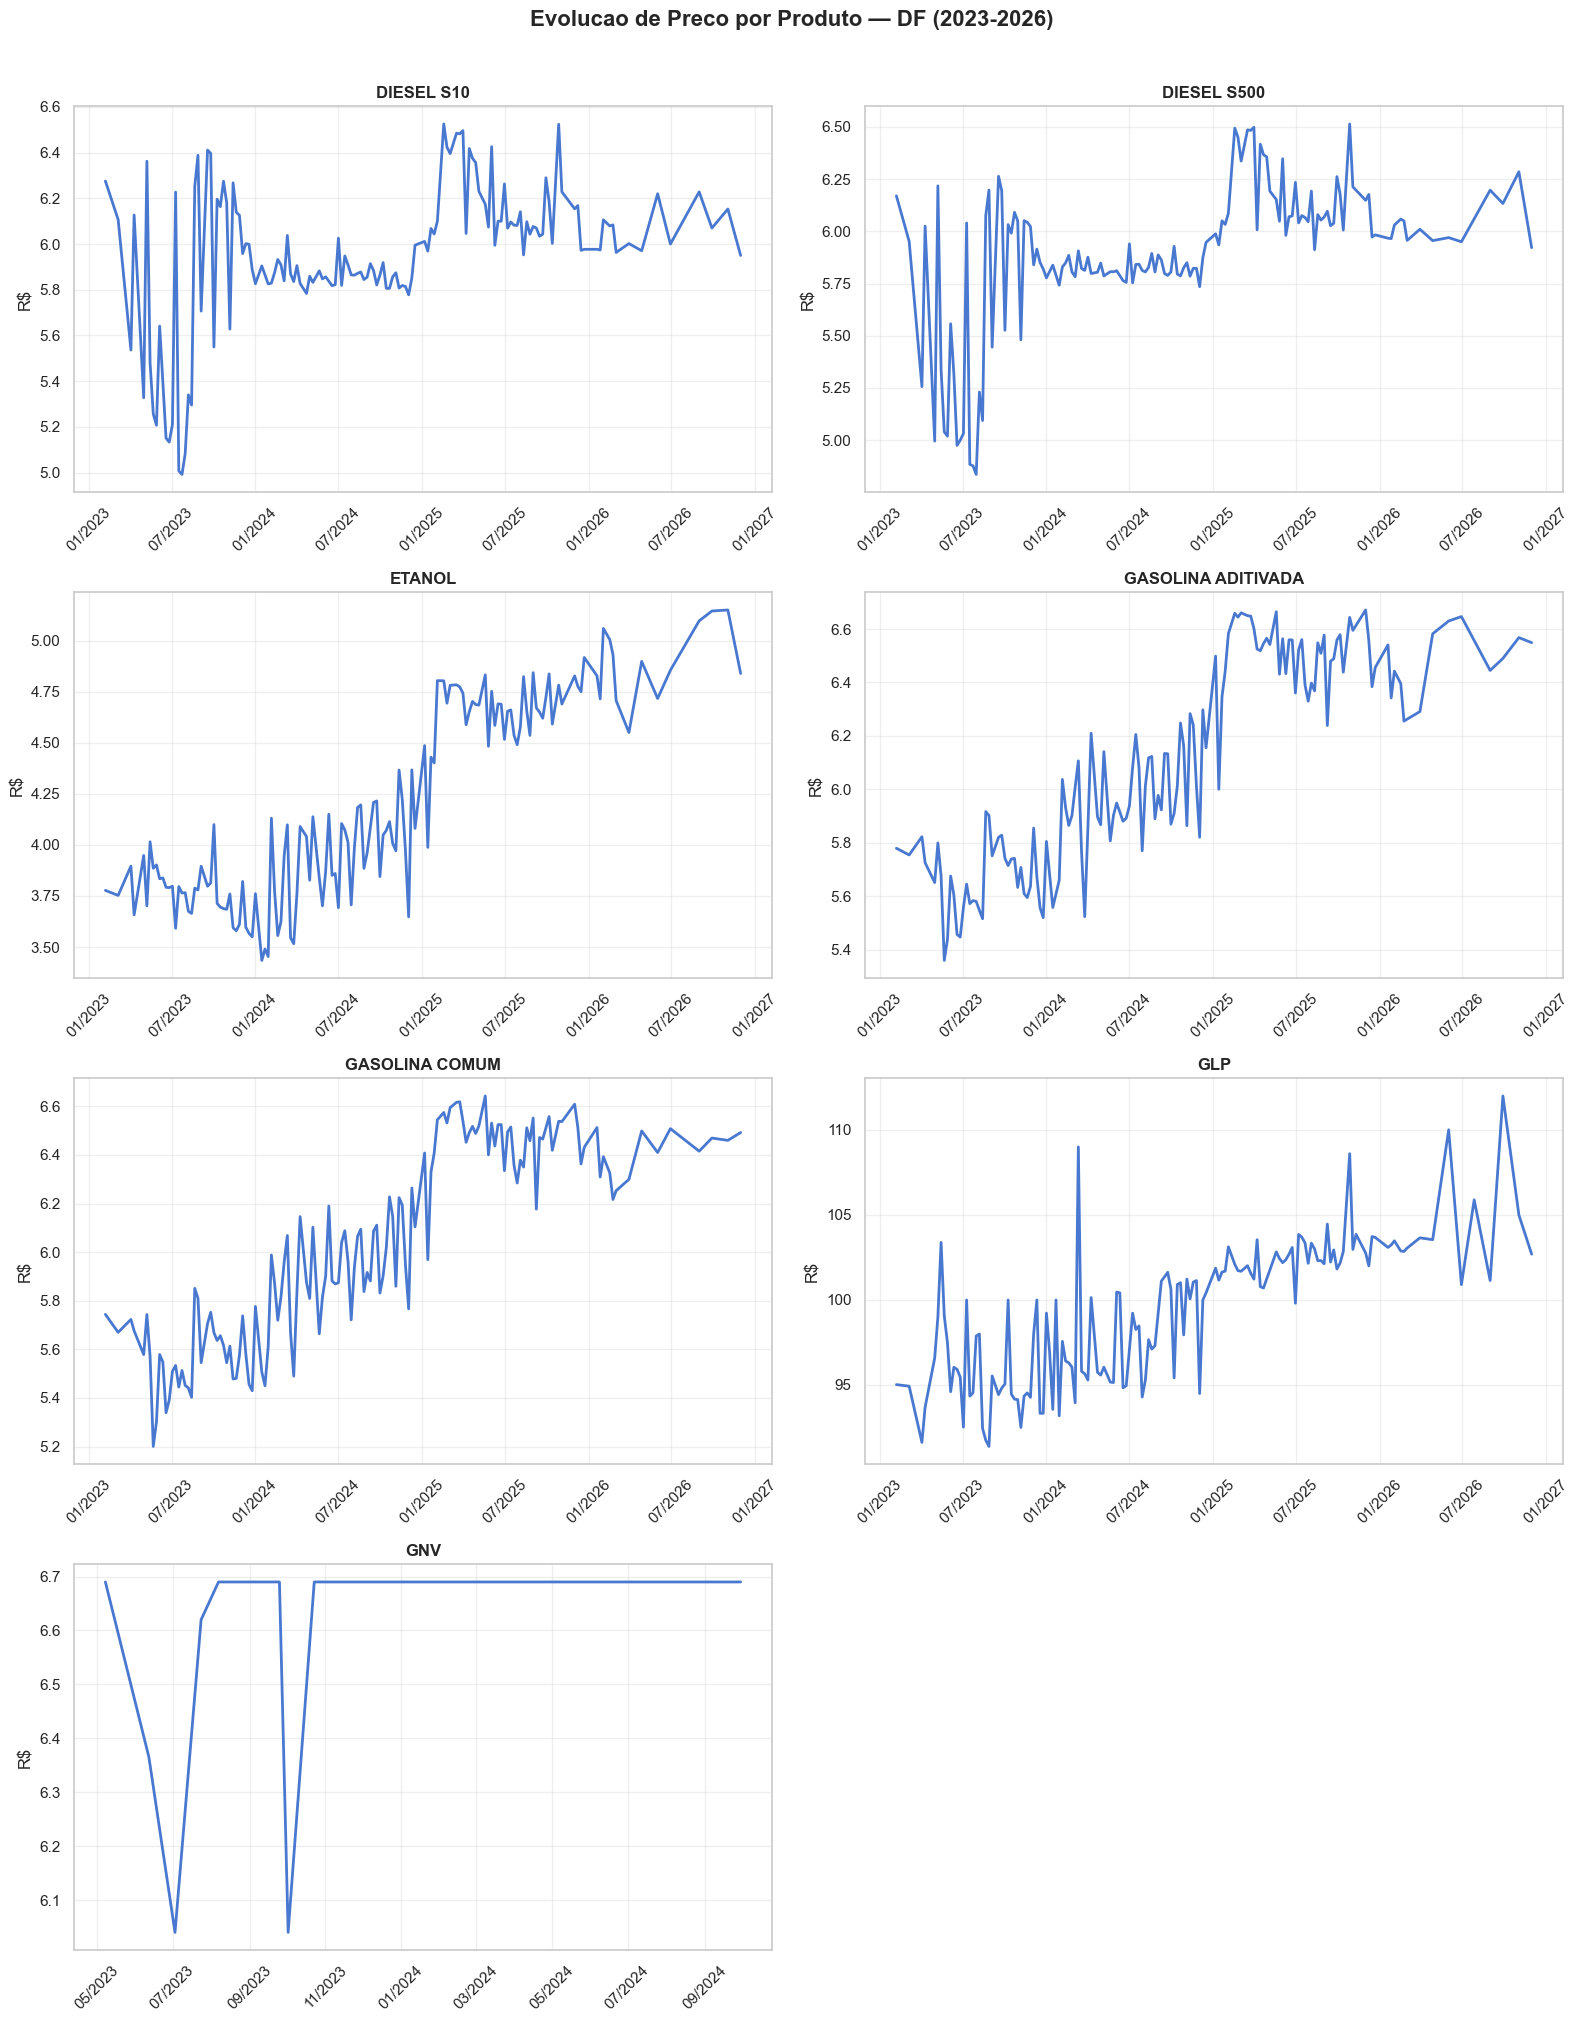

In [33]:
# Todos os produtos
preco_semanal_all = df.groupby(['semana', 'produto'])['preco_revenda'].mean().reset_index()

fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

for i, produto in enumerate(sorted(df['produto'].unique())):
    data = preco_semanal_all[preco_semanal_all['produto'] == produto]
    axes[i].plot(data['semana'], data['preco_revenda'], linewidth=2)
    axes[i].set_title(produto, fontweight='bold')
    axes[i].set_ylabel('R$')
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%m/%Y'))
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(True, alpha=0.3)

# Esconde subplot vazio se tiver numero impar de produtos
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Evolucao de Preco por Produto — DF (2023-2026)', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../../data/processed/evolucao_precos.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Comparacao entre Produtos

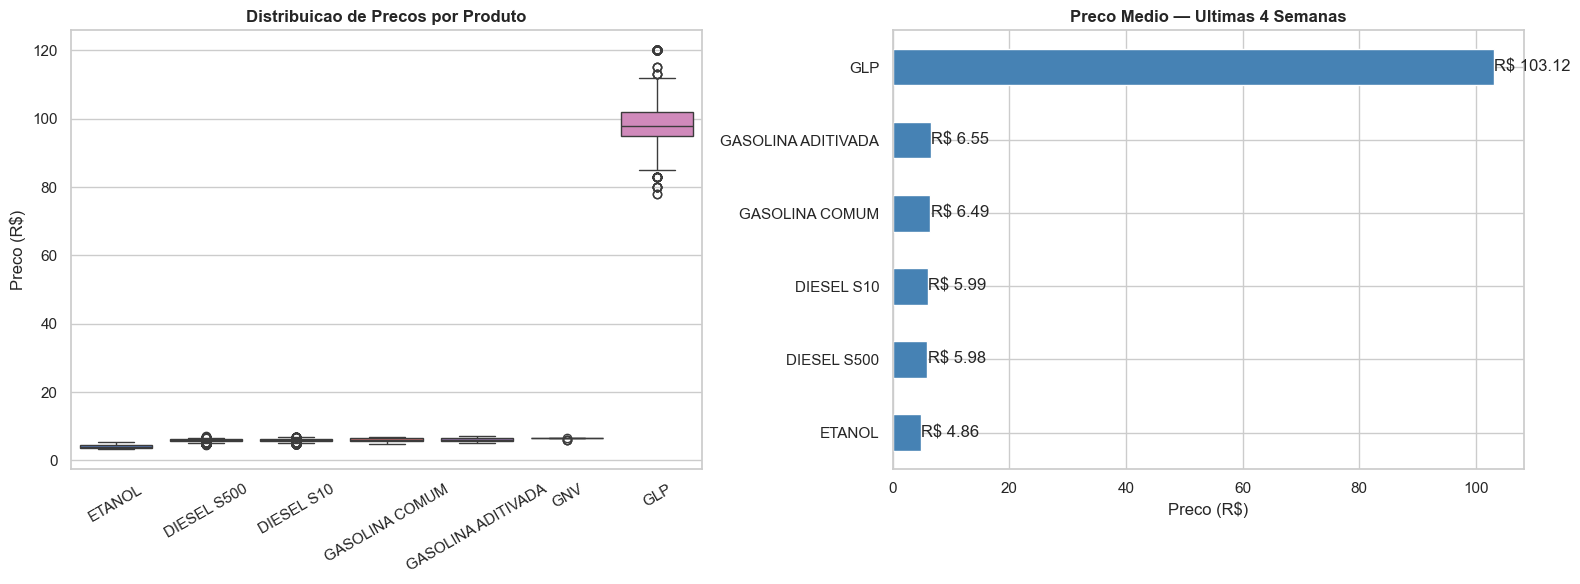

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot
ordem = df.groupby('produto')['preco_revenda'].median().sort_values().index
sns.boxplot(data=df, x='produto', y='preco_revenda', order=ordem, ax=axes[0], palette='muted')
axes[0].set_title('Distribuicao de Precos por Produto', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Preco (R$)')
axes[0].tick_params(axis='x', rotation=30)

# Preco medio atual (ultimas 4 semanas)
ultima_data = df['semana'].max()
df_recente = df[df['semana'] >= ultima_data - pd.Timedelta(weeks=4)]
preco_atual = df_recente.groupby('produto')['preco_revenda'].mean().sort_values()
preco_atual.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Preco Medio — Ultimas 4 Semanas', fontweight='bold')
axes[1].set_xlabel('Preco (R$)')
axes[1].set_ylabel('')
for i, v in enumerate(preco_atual):
    axes[1].text(v + 0.02, i, f'R$ {v:.2f}', va='center')

plt.tight_layout()
plt.show()

## 4. Variacao por Regiao do DF

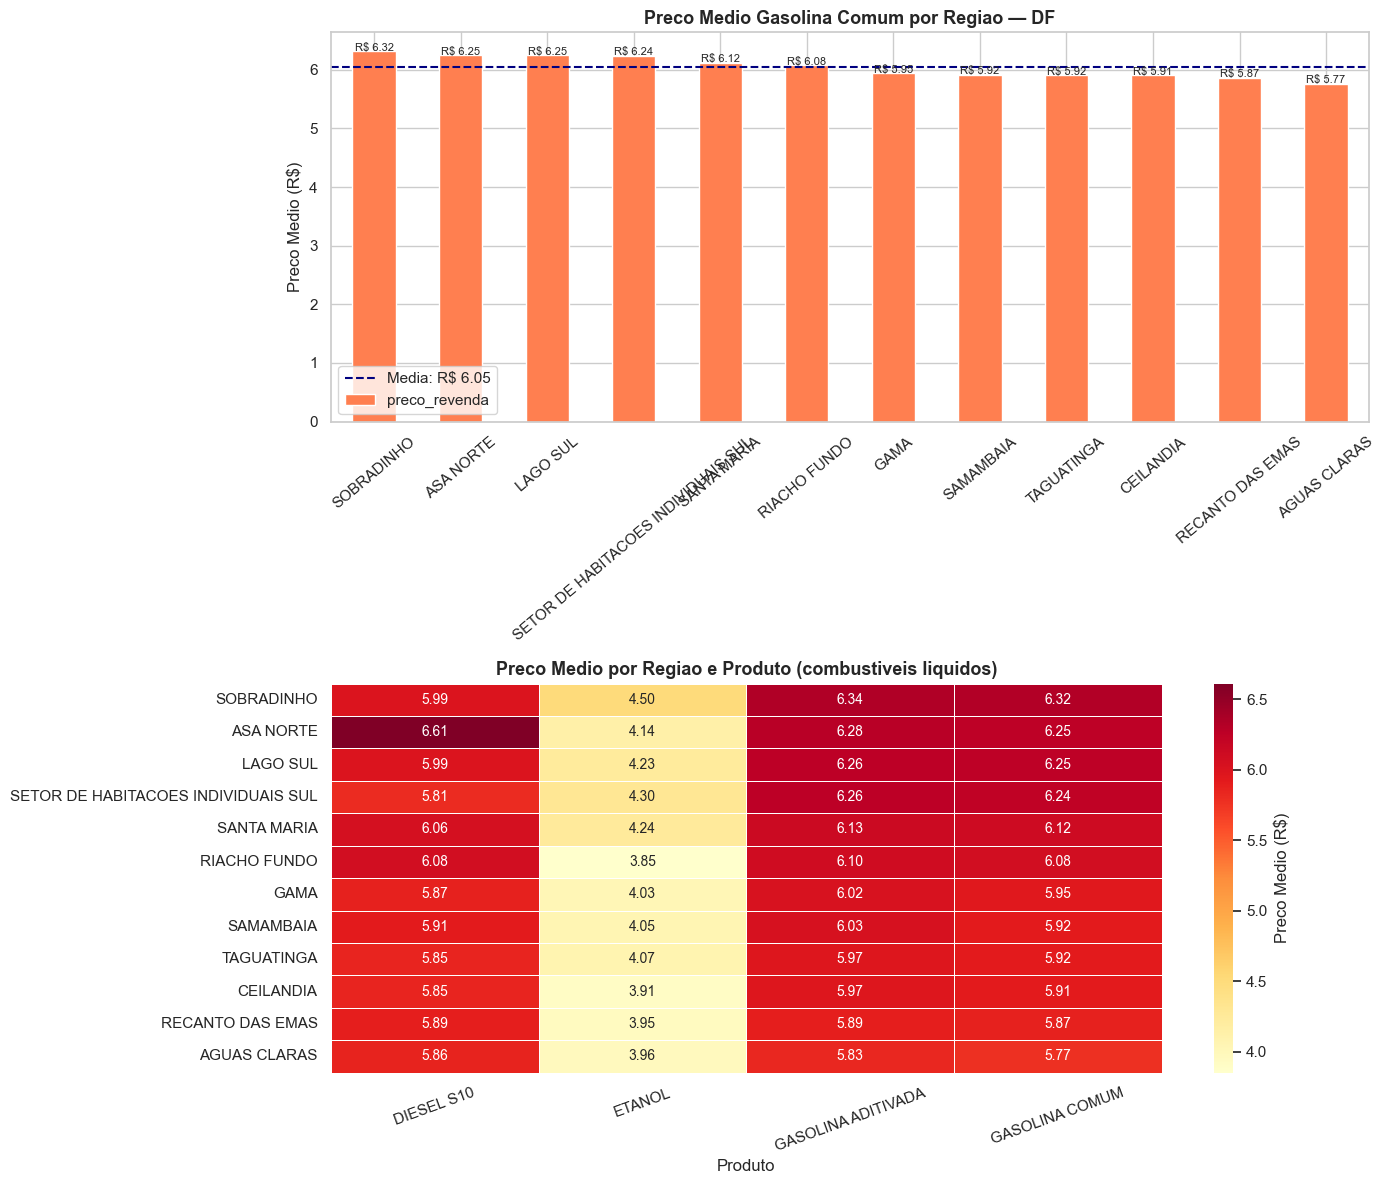

In [35]:
# Top regioes por volume de registros
top_regioes = df['regiao'].value_counts().head(12).index
df_reg = df[df['regiao'].isin(top_regioes)]

preco_reg = df_reg[df_reg['produto'] == 'GASOLINA COMUM'].groupby('regiao')['preco_revenda'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Barplot por regiao
preco_reg.plot(kind='bar', ax=axes[0], color='coral')
axes[0].set_title('Preco Medio Gasolina Comum por Regiao — DF', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Preco Medio (R$)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=40)
axes[0].axhline(preco_reg.mean(), color='navy', linestyle='--', label=f'Media: R$ {preco_reg.mean():.2f}')
for i, v in enumerate(preco_reg):
    axes[0].text(i, v + 0.005, f'R$ {v:.2f}', ha='center', fontsize=8)
axes[0].legend()

# Heatmap legivel — apenas produtos liquidos, top 12 regioes
produtos_liquidos = ['GASOLINA COMUM', 'GASOLINA ADITIVADA', 'ETANOL', 'DIESEL S10']
df_heat = df_reg[df_reg['produto'].isin(produtos_liquidos)]
heatmap_data = df_heat.groupby(['regiao', 'produto'])['preco_revenda'].mean().unstack().round(2)
heatmap_data = heatmap_data.sort_values('GASOLINA COMUM', ascending=False)

sns.heatmap(
    heatmap_data,
    annot=True, fmt='.2f',
    cmap='YlOrRd',
    ax=axes[1],
    linewidths=0.5,
    annot_kws={'size': 10},
    cbar_kws={'label': 'Preco Medio (R$)'}
)
axes[1].set_title('Preco Medio por Regiao e Produto (combustiveis liquidos)', fontweight='bold', fontsize=13)
axes[1].set_ylabel('')
axes[1].set_xlabel('Produto')
axes[1].tick_params(axis='x', rotation=20)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

## 5. Postos Mais Caros vs Mais Baratos

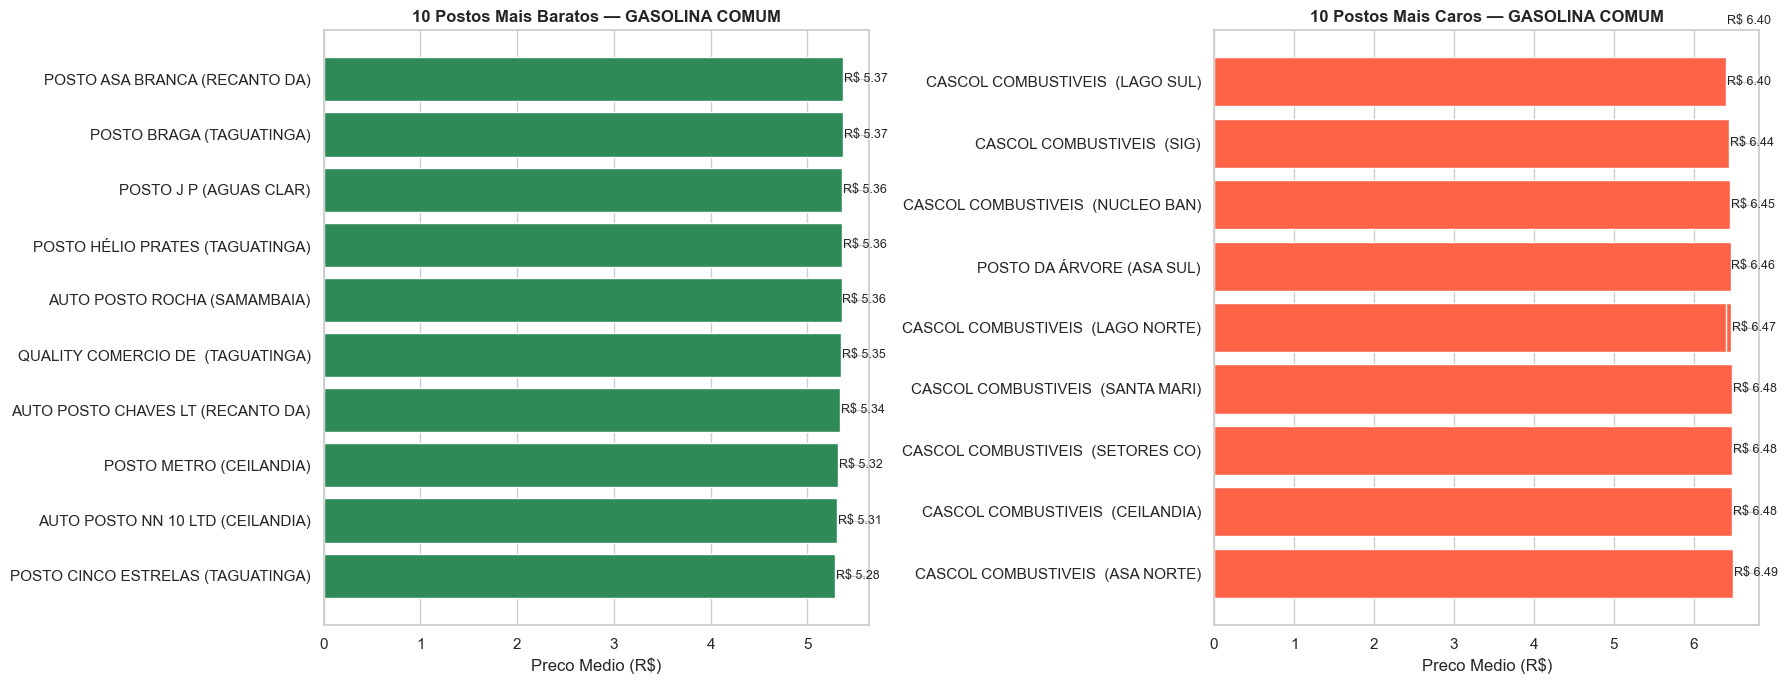

Diferenca entre mais barato e mais caro: R$ 1.21


In [36]:
produto_analise = 'GASOLINA COMUM'
df_gas = df[df['produto'] == produto_analise]

preco_posto = df_gas.groupby(['cnpj', 'nome_fantasia', 'regiao', 'bandeira'])['preco_revenda'].agg(['mean', 'count']).reset_index()
preco_posto.columns = ['cnpj', 'nome', 'regiao', 'bandeira', 'preco_medio', 'n_registros']
preco_posto = preco_posto[preco_posto['n_registros'] >= 5].sort_values('preco_medio')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 10 mais baratos
top_baratos = preco_posto.head(10)
label_b = top_baratos.apply(lambda r: f"{r['nome'][:20]} ({r['regiao'][:10]})", axis=1)
axes[0].barh(label_b, top_baratos['preco_medio'], color='seagreen')
axes[0].set_title(f'10 Postos Mais Baratos — {produto_analise}', fontweight='bold')
axes[0].set_xlabel('Preco Medio (R$)')
for i, v in enumerate(top_baratos['preco_medio']):
    axes[0].text(v + 0.01, i, f'R$ {v:.2f}', va='center', fontsize=9)

# 10 mais caros
top_caros = preco_posto.tail(10).sort_values('preco_medio', ascending=False)
label_c = top_caros.apply(lambda r: f"{r['nome'][:20]} ({r['regiao'][:10]})", axis=1)
axes[1].barh(label_c, top_caros['preco_medio'], color='tomato')
axes[1].set_title(f'10 Postos Mais Caros — {produto_analise}', fontweight='bold')
axes[1].set_xlabel('Preco Medio (R$)')
for i, v in enumerate(top_caros['preco_medio']):
    axes[1].text(v + 0.01, i, f'R$ {v:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()
print(f'Diferenca entre mais barato e mais caro: R$ {preco_posto.preco_medio.max() - preco_posto.preco_medio.min():.2f}')

## 6. Sazonalidade

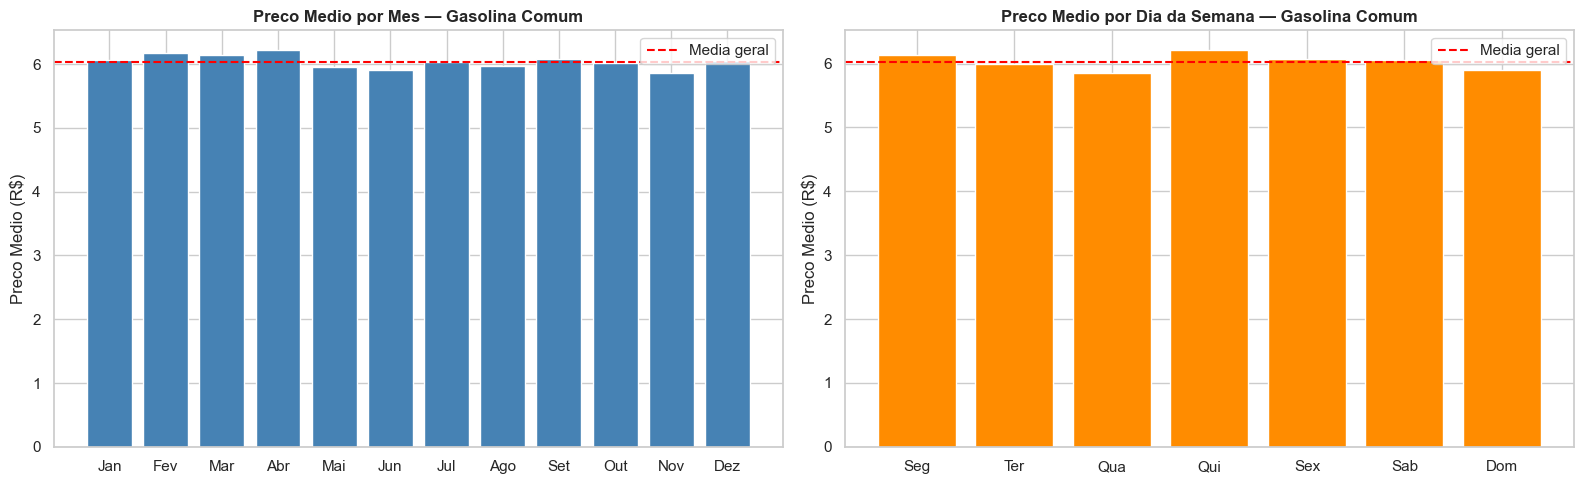

In [21]:
meses = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']
dias = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dias_pt = ['Seg','Ter','Qua','Qui','Sex','Sab','Dom']

df_gas = df[df['produto'] == 'GASOLINA COMUM'].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Por mes
preco_mes = df_gas.groupby('mes')['preco_revenda'].mean()
axes[0].bar(meses, preco_mes.reindex(range(1,13)), color='steelblue')
axes[0].set_title('Preco Medio por Mes — Gasolina Comum', fontweight='bold')
axes[0].set_ylabel('Preco Medio (R$)')
axes[0].axhline(preco_mes.mean(), color='red', linestyle='--', label='Media geral')
axes[0].legend()

# Por dia da semana
preco_dia = df_gas.groupby('dia_semana')['preco_revenda'].mean().reindex(dias)
axes[1].bar(dias_pt, preco_dia.values, color='darkorange')
axes[1].set_title('Preco Medio por Dia da Semana — Gasolina Comum', fontweight='bold')
axes[1].set_ylabel('Preco Medio (R$)')
axes[1].axhline(preco_dia.mean(), color='red', linestyle='--', label='Media geral')
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Outliers e Dados Suspeitos

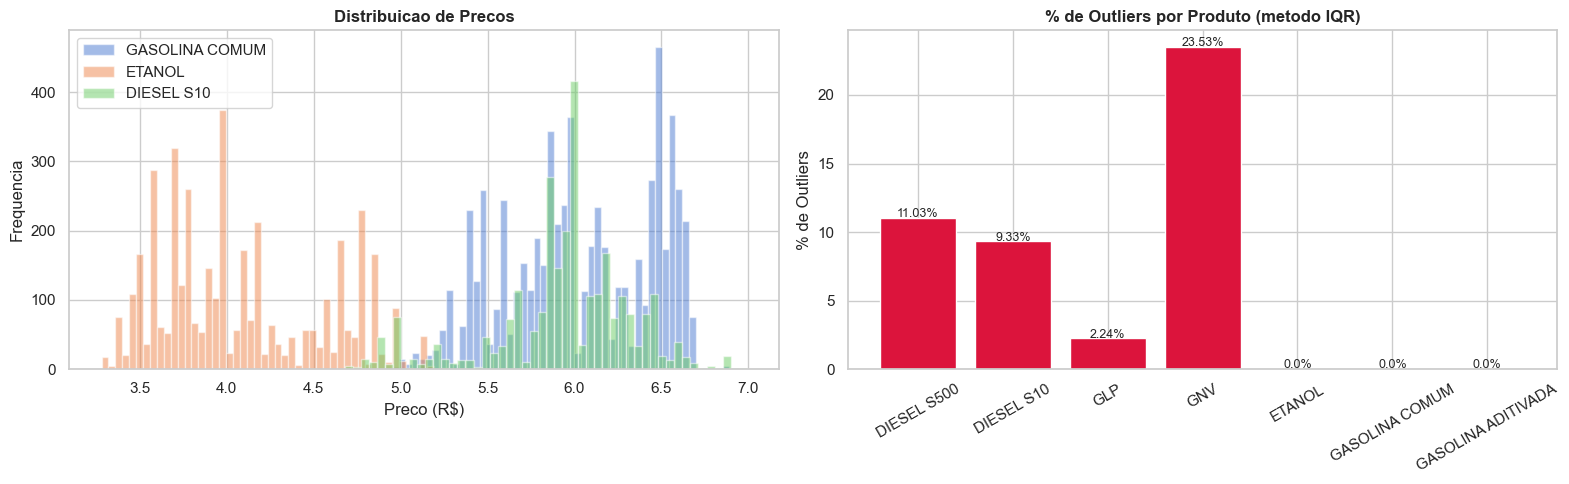

           produto  n_outliers   pct
       DIESEL S500         291 11.03
        DIESEL S10         260  9.33
               GLP         123  2.24
               GNV           4 23.53
            ETANOL           0  0.00
    GASOLINA COMUM           0  0.00
GASOLINA ADITIVADA           0  0.00


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histograma de precos
for produto in ['GASOLINA COMUM', 'ETANOL', 'DIESEL S10']:
    subset = df[df['produto'] == produto]['preco_revenda']
    axes[0].hist(subset, bins=50, alpha=0.5, label=produto)
axes[0].set_title('Distribuicao de Precos', fontweight='bold')
axes[0].set_xlabel('Preco (R$)')
axes[0].set_ylabel('Frequencia')
axes[0].legend()

# Outliers via IQR por produto
outliers_list = []
for produto in df['produto'].unique():
    subset = df[df['produto'] == produto]['preco_revenda']
    Q1, Q3 = subset.quantile(0.25), subset.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_outliers = ((subset < lower) | (subset > upper)).sum()
    outliers_list.append({'produto': produto, 'n_outliers': n_outliers, 'pct': round(n_outliers/len(subset)*100, 2)})

df_outliers = pd.DataFrame(outliers_list).sort_values('n_outliers', ascending=False)
axes[1].bar(df_outliers['produto'], df_outliers['pct'], color='crimson')
axes[1].set_title('% de Outliers por Produto (metodo IQR)', fontweight='bold')
axes[1].set_ylabel('% de Outliers')
axes[1].tick_params(axis='x', rotation=30)
for i, v in enumerate(df_outliers['pct']):
    axes[1].text(i, v + 0.05, f'{v}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()
print(df_outliers.to_string(index=False))

In [23]:
# Postos com comportamento suspeito: coeficiente de variacao alto
cv_posto = df.groupby(['cnpj', 'nome_fantasia', 'produto'])['preco_revenda'].agg(['mean', 'std', 'count']).reset_index()
cv_posto['cv'] = (cv_posto['std'] / cv_posto['mean'] * 100).round(2)
cv_posto = cv_posto[cv_posto['count'] >= 10].sort_values('cv', ascending=False)

print('=== Top 10 Postos com Maior Variacao de Preco ===')
print(cv_posto.head(10)[['nome_fantasia', 'produto', 'mean', 'std', 'cv', 'count']].to_string(index=False))

=== Top 10 Postos com Maior Variacao de Preco ===
  nome_fantasia     produto     mean      std    cv  count
            NAN      ETANOL 4.105682 0.536116 13.06     88
POSTO CEILANDIA      ETANOL 3.955088 0.503814 12.74     57
            NAN      ETANOL 4.199820 0.518836 12.35    111
            NAN      ETANOL 4.190000 0.497203 11.87    117
            NAN      ETANOL 4.011139 0.470311 11.73     79
            NAN      ETANOL 4.161545 0.485388 11.66    123
   POSTO BRASAL DIESEL S500 5.628710 0.651663 11.58     31
            NAN      ETANOL 4.199919 0.471067 11.22    123
      POSTO J P  DIESEL S10 5.449375 0.606151 11.12     16
   POSTO BRASAL  DIESEL S10 5.700667 0.631511 11.08     30


## 8. Resumo Final para o TCC

In [26]:
print('=' * 50)
print('RESUMO EDA — PRECOS DE COMBUSTIVEIS DF')
print('=' * 50)
print(f'Periodo analisado: {df.data_coleta.min().date()} a {df.data_coleta.max().date()}')
print(f'Total de registros: {len(df):,}')
print(f'Postos unicos: {df.cnpj.nunique()}')
print(f'Regiões: {df.regiao.nunique()}')
print(f'Produtos: {df.produto.nunique()}')
print()
print('Preco medio atual por produto (ultimas 4 semanas):')
ultima = df['semana'].max()
recente = df[df['semana'] >= ultima - pd.Timedelta(weeks=4)]
print(recente.groupby('produto')['preco_revenda'].mean().round(2).to_string())
print()
print('Variacao total de preco (min -> max) por produto:')
print(df.groupby('produto')['preco_revenda'].agg(lambda x: f'R$ {x.min():.2f} -> R$ {x.max():.2f}').to_string())

RESUMO EDA — PRECOS DE COMBUSTIVEIS DF
Periodo analisado: 2023-02-10 a 2026-12-02
Total de registros: 27,213
Postos unicos: 238
Regiões: 38
Produtos: 7

Preco medio atual por produto (ultimas 4 semanas):
produto
DIESEL S10              5.99
DIESEL S500             5.98
ETANOL                  4.86
GASOLINA ADITIVADA      6.55
GASOLINA COMUM          6.49
GLP                   103.12

Variacao total de preco (min -> max) por produto:
produto
DIESEL S10               R$ 4.68 -> R$ 6.99
DIESEL S500              R$ 4.65 -> R$ 7.02
ETANOL                   R$ 3.28 -> R$ 5.27
GASOLINA ADITIVADA       R$ 4.99 -> R$ 7.29
GASOLINA COMUM           R$ 4.95 -> R$ 6.89
GLP                   R$ 77.99 -> R$ 120.00
GNV                      R$ 6.04 -> R$ 6.69
